In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
iris = load_iris()
X = iris.data  # features only (unsupervised)
df = pd.DataFrame(X, columns=iris.feature_names)

# Display first 5 rows
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [5]:
for i, val in enumerate(inertia, start=1):
    print(f"Number of clusters = {i}, Inertia = {val:.2f}")

Number of clusters = 1, Inertia = 600.00
Number of clusters = 2, Inertia = 222.36
Number of clusters = 3, Inertia = 191.02
Number of clusters = 4, Inertia = 114.35
Number of clusters = 5, Inertia = 91.05
Number of clusters = 6, Inertia = 81.55
Number of clusters = 7, Inertia = 80.78
Number of clusters = 8, Inertia = 64.43
Number of clusters = 9, Inertia = 55.71
Number of clusters = 10, Inertia = 51.12


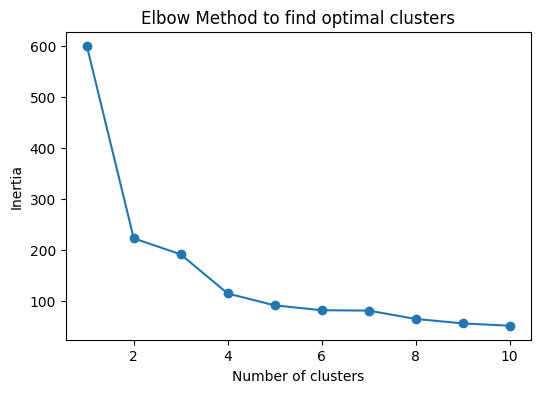

In [6]:
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method to find optimal clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster info to dataframe
df['Cluster'] = clusters
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


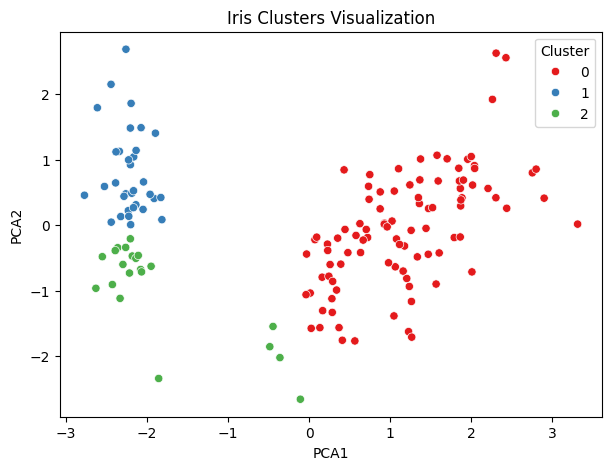

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

# Plot clusters
plt.figure(figsize=(7,5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title("Iris Clusters Visualization")
plt.show()